In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from ultralytics import YOLO

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
model = YOLO("yolo11n.pt")

print("YOLO model loaded.")

YOLO model loaded.


In [3]:
#create input and output folders
INPUT_DIR = "images"
OUTPUT_DIR = "outputs"

os.makedirs(INPUT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Input folder :", INPUT_DIR)
print("Output folder:", OUTPUT_DIR)

Input folder : images
Output folder: outputs


In [5]:
# put an image into the input folder
import glob

image_files = glob.glob(os.path.join(INPUT_DIR, "*"))

print("Images found:", len(image_files))

for image in image_files:
    print(os.path.basename(image))

Images found: 2
Screenshot 2026-01-17 160741.png
Screenshot 2026-08-17 124842.png


In [6]:
#select an image
IMAGE_PATH = image_files[0]

print("Selected image:", IMAGE_PATH)

Selected image: images\Screenshot 2026-01-17 160741.png


In [7]:
#create a reusable detection function
def detect_objects(image_path, model, confidence=0.25):
    

    results = model(
        image_path,
        conf=confidence,
        verbose=False
    )

    return results[0]


result = detect_objects(
    IMAGE_PATH,
    model
)

print("Detection completed.")
print("Number of detections:", len(result.boxes))

Detection completed.
Number of detections: 11


In [8]:
# extract detections into structured data
def extract_detections(result):
    detections = []

    boxes = result.boxes

    for i in range(len(boxes)):

        class_id = int(boxes.cls[i].item())
        confidence = float(boxes.conf[i].item())

        x1, y1, x2, y2 = (
            boxes.xyxy[i]
            .cpu()
            .numpy()
            .astype(int)
        )

        detections.append({
            "class_id": class_id,
            "class_name": result.names[class_id],
            "confidence": confidence,
            "box": (x1, y1, x2, y2)
        })

    return detections


detections = extract_detections(result)

print("Number of detections:", len(detections))

for detection in detections:
    print(detection)

Number of detections: 11
{'class_id': 0, 'class_name': 'person', 'confidence': 0.8378200531005859, 'box': (np.int64(367), np.int64(139), np.int64(447), np.int64(410))}
{'class_id': 0, 'class_name': 'person', 'confidence': 0.8260025978088379, 'box': (np.int64(281), np.int64(146), np.int64(352), np.int64(412))}
{'class_id': 0, 'class_name': 'person', 'confidence': 0.8144320845603943, 'box': (np.int64(461), np.int64(153), np.int64(540), np.int64(410))}
{'class_id': 0, 'class_name': 'person', 'confidence': 0.813205361366272, 'box': (np.int64(88), np.int64(125), np.int64(205), np.int64(407))}
{'class_id': 0, 'class_name': 'person', 'confidence': 0.8108916878700256, 'box': (np.int64(197), np.int64(109), np.int64(277), np.int64(406))}
{'class_id': 0, 'class_name': 'person', 'confidence': 0.7893381118774414, 'box': (np.int64(562), np.int64(152), np.int64(637), np.int64(406))}
{'class_id': 0, 'class_name': 'person', 'confidence': 0.7395572662353516, 'box': (np.int64(631), np.int64(109), np.int6

In [9]:
#create a detection summary
from collections import Counter

class_counts = Counter(
    detection["class_name"]
    for detection in detections
)

print("Detected objects:\n")

for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

Detected objects:

person: 9
sports ball: 2


In [10]:
#filter detections by confidence
def filter_by_confidence(detections, min_confidence=0.50):
    return [
        detection
        for detection in detections
        if detection["confidence"] >= min_confidence
    ]


filtered_detections = filter_by_confidence(
    detections,
    min_confidence=0.50
)

print("Original detections:", len(detections))
print("Filtered detections:", len(filtered_detections))

Original detections: 11
Filtered detections: 9


In [11]:
#filter by object class
def filter_by_class(detections, class_names):
    return [
        detection
        for detection in detections
        if detection["class_name"] in class_names
    ]


wanted_classes = [
    "person",
    "laptop",
    "cell phone"
]

selected_detections = filter_by_class(
    filtered_detections,
    wanted_classes
)

print("Selected detections:\n")

for detection in selected_detections:
    print(
        detection["class_name"],
        f"({detection['confidence']:.2f})"
    )

Selected detections:

person (0.84)
person (0.83)
person (0.81)
person (0.81)
person (0.81)
person (0.79)
person (0.74)
person (0.51)


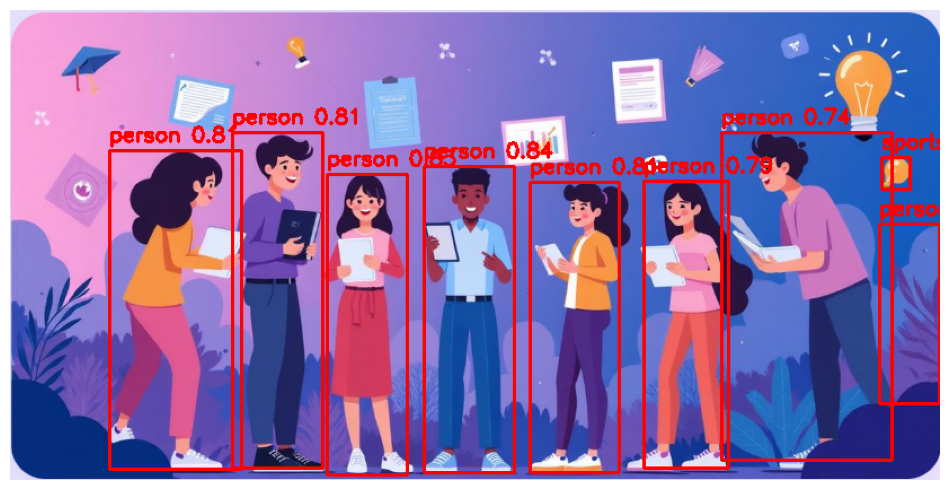

In [12]:
# draw our own detection boxes
def draw_detections(image_path, detections):
    
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    for detection in detections:

        x1, y1, x2, y2 = detection["box"]
        class_name = detection["class_name"]
        confidence = detection["confidence"]

        cv2.rectangle(
            image,
            (x1, y1),
            (x2, y2),
            (255, 0, 0),
            2
        )

        label = f"{class_name} {confidence:.2f}"

        cv2.putText(
            image,
            label,
            (x1, max(y1 - 8, 15)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 0, 0),
            2
        )

    return image


annotated_image = draw_detections(
    IMAGE_PATH,
    filtered_detections
)

plt.figure(figsize=(12, 8))
plt.imshow(annotated_image)
plt.axis("off")
plt.show()

In [13]:
#save the annotated image
output_path = os.path.join(
    OUTPUT_DIR,
    "annotated_result.jpg"
)

image_bgr = cv2.cvtColor(
    annotated_image,
    cv2.COLOR_RGB2BGR
)

cv2.imwrite(
    output_path,
    image_bgr
)

print("Saved:", output_path)

Saved: outputs\annotated_result.jpg


In [14]:
#crop detected objects
def crop_detections(image_path, detections, output_dir):
    
    image = cv2.imread(image_path)

    os.makedirs(output_dir, exist_ok=True)

    saved_files = []

    for i, detection in enumerate(detections):

        x1, y1, x2, y2 = detection["box"]
        class_name = detection["class_name"]

        crop = image[y1:y2, x1:x2]

        filename = f"{class_name}_{i}.jpg"
        save_path = os.path.join(
            output_dir,
            filename
        )

        cv2.imwrite(save_path, crop)

        saved_files.append(save_path)

    return saved_files


crop_dir = os.path.join(
    OUTPUT_DIR,
    "crops"
)

saved_crops = crop_detections(
    IMAGE_PATH,
    selected_detections,
    crop_dir
)

print("Saved crops:")

for path in saved_crops:
    print(path)

Saved crops:
outputs\crops\person_0.jpg
outputs\crops\person_1.jpg
outputs\crops\person_2.jpg
outputs\crops\person_3.jpg
outputs\crops\person_4.jpg
outputs\crops\person_5.jpg
outputs\crops\person_6.jpg
outputs\crops\person_7.jpg


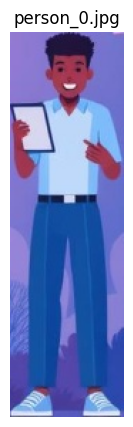

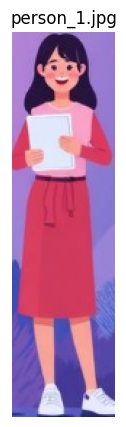

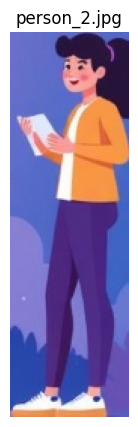

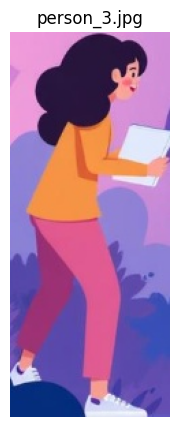

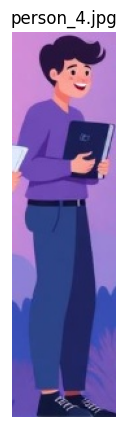

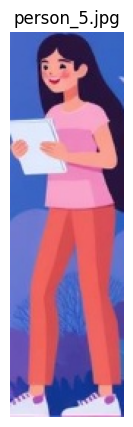

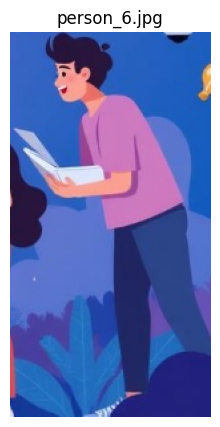

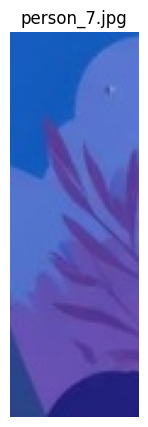

In [15]:
# visualize the crops
for crop_path in saved_crops:

    crop = cv2.imread(crop_path)
    crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(5, 5))
    plt.imshow(crop)
    plt.title(os.path.basename(crop_path))
    plt.axis("off")
    plt.show()

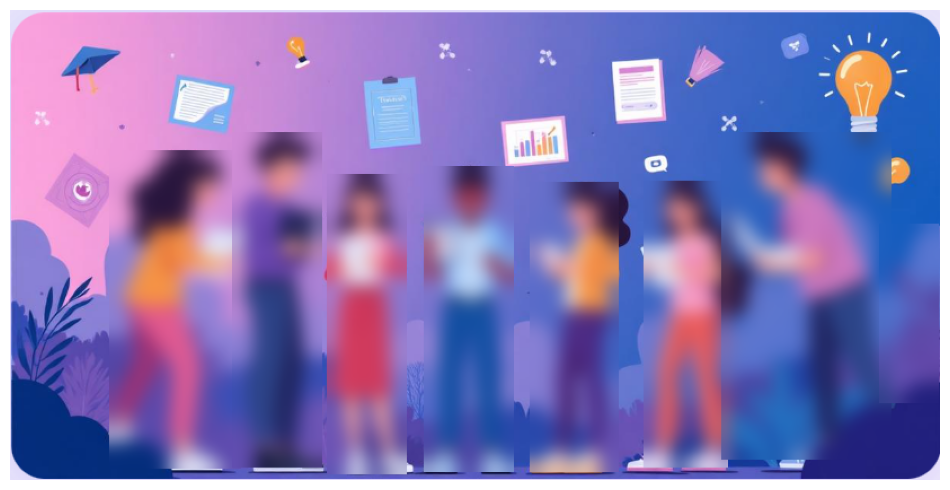

In [16]:
# blur a detected object
def blur_detections(image_path, detections):
    
    image = cv2.imread(image_path)

    for detection in detections:

        x1, y1, x2, y2 = detection["box"]

        roi = image[y1:y2, x1:x2]

        if roi.size == 0:
            continue

        blurred = cv2.GaussianBlur(
            roi,
            (51, 51),
            0
        )

        image[y1:y2, x1:x2] = blurred

    return image


blurred_image = blur_detections(
    IMAGE_PATH,
    selected_detections
)

plt.figure(figsize=(12, 8))
plt.imshow(
    cv2.cvtColor(blurred_image, cv2.COLOR_BGR2RGB)
)
plt.axis("off")
plt.show()

In [17]:
blur_output = os.path.join(
    OUTPUT_DIR,
    "blurred_result.jpg"
)

cv2.imwrite(
    blur_output,
    blurred_image
)

print("Saved:", blur_output)

Saved: outputs\blurred_result.jpg


In [18]:
# create one reusable pipeline function
def process_image(
    image_path,
    model,
    output_dir,
    confidence=0.50,
    target_classes=None
):

    # 1. Detect
    result = model(
        image_path,
        conf=confidence,
        verbose=False
    )[0]

    # 2. Extract
    detections = extract_detections(result)

    # 3. Filter classes
    if target_classes is not None:
        detections = filter_by_class(
            detections,
            target_classes
        )

    # 4. Draw
    annotated = draw_detections(
        image_path,
        detections
    )

    # 5. Save
    filename = os.path.basename(image_path)
    output_path = os.path.join(
        output_dir,
        f"processed_{filename}"
    )

    cv2.imwrite(
        output_path,
        cv2.cvtColor(
            annotated,
            cv2.COLOR_RGB2BGR
        )
    )

    return detections, output_path


detections, output_path = process_image(
    IMAGE_PATH,
    model,
    OUTPUT_DIR,
    confidence=0.50
)

print("Processing complete.")
print("Output:", output_path)
print("Objects detected:", len(detections))

Processing complete.
Output: outputs\processed_Screenshot 2026-01-17 160741.png
Objects detected: 9


In [19]:
# test the pipeline on multiple images
for image_path in image_files[:5]:

    detections, output_path = process_image(
        image_path,
        model,
        OUTPUT_DIR,
        confidence=0.50
    )

    print(
        os.path.basename(image_path),
        "→",
        len(detections),
        "objects"
    )

Screenshot 2026-01-17 160741.png → 9 objects
Screenshot 2026-08-17 124842.png → 1 objects


In [20]:
#create a simple object report
for image_path in image_files[:5]:

    result = model(
        image_path,
        conf=0.50,
        verbose=False
    )[0]

    detections = extract_detections(result)

    counts = {}

    for detection in detections:

        name = detection["class_name"]

        counts[name] = counts.get(name, 0) + 1

    print("\n", os.path.basename(image_path))

    for name, count in counts.items():
        print(f"  {name}: {count}")


 Screenshot 2026-01-17 160741.png
  person: 8
  sports ball: 1

 Screenshot 2026-08-17 124842.png
  person: 1


In [21]:
# changes the target class
target_classes = ["person"]

detections, output_path = process_image(
    IMAGE_PATH,
    model,
    OUTPUT_DIR,
    confidence=0.40,
    target_classes=target_classes
)

print("Detected:", len(detections))
print("Saved:", output_path)

Detected: 8
Saved: outputs\processed_Screenshot 2026-01-17 160741.png
